In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import fetch_california_housing

# Loading the raw data from the library
data = fetch_california_housing()

# Create the DataFrame (df)
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

# Define Features (X) and Target (y)
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# Split into training and validation sets (80% train, 20% validation)
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.2, random_state=1)

# Define the model
model = RandomForestRegressor(n_estimators=100, random_state=1)

# Fit the model on the training data
model.fit(train_X, train_y)

# Validate the model on unseen data
predictions = model.predict(val_X)
mae = mean_absolute_error(val_y, predictions)

print(f"Validation Mean Absolute Error: {mae:.4f}")


Validation Mean Absolute Error: 0.3266


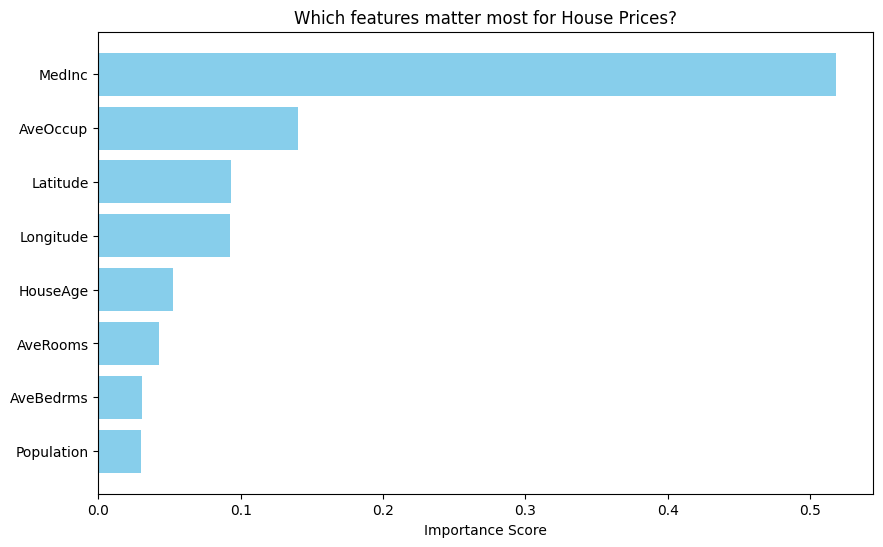

In [7]:
import matplotlib.pyplot as plt

# Get feature importance from the model
importances = model.feature_importances_
feature_names = X.columns

# Sort them for a better looking plot
sorted_indices = importances.argsort()

plt.figure(figsize=(10, 6))
plt.barh(feature_names[sorted_indices], importances[sorted_indices], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Which features matter most for House Prices?')
plt.show()